# Since, our last approach of extracting the features failed and was also much more computionally expensive (only with the visual case)

Problem with the previous ball collison detection using average intensity: 
- Average Intensity detected collison but for the case where ball disappered above it also flagged it as a collison but it was not in reality. Since, audio is only generated when ball hits the wall.
- 100 fps framing was computationally expensive.

Now, we will try to track the ball's coordinates with cv2 library and estimate the boundaries and then generate collision time stamps. 
Finally, we will devise a loss function for matching the features (audio and visual).

Ball missing at time: 0.57 sec
Ball missing at time: 0.58 sec
Ball missing at time: 0.60 sec
Ball missing at time: 0.62 sec
Ball missing at time: 0.63 sec
Ball missing at time: 0.65 sec
Ball missing at time: 0.67 sec
Ball missing at time: 0.68 sec
Ball missing at time: 0.70 sec
Ball missing at time: 0.72 sec
Ball missing at time: 0.73 sec
Ball missing at time: 0.75 sec
Ball missing at time: 0.77 sec
Ball missing at time: 0.78 sec
Ball missing at time: 0.80 sec
Ball missing at time: 0.82 sec
Ball missing at time: 0.83 sec
Ball missing at time: 0.85 sec
Ball missing at time: 0.87 sec
Ball missing at time: 0.88 sec
Ball missing at time: 0.90 sec
Ball missing at time: 0.92 sec
Ball missing at time: 0.93 sec
Ball missing at time: 0.95 sec
Ball missing at time: 0.97 sec
Ball missing at time: 0.98 sec
Ball missing at time: 1.00 sec
Ball missing at time: 1.02 sec
Ball missing at time: 1.03 sec
Ball missing at time: 1.05 sec
Ball missing at time: 1.07 sec
Ball missing at time: 1.08 sec
Ball mis

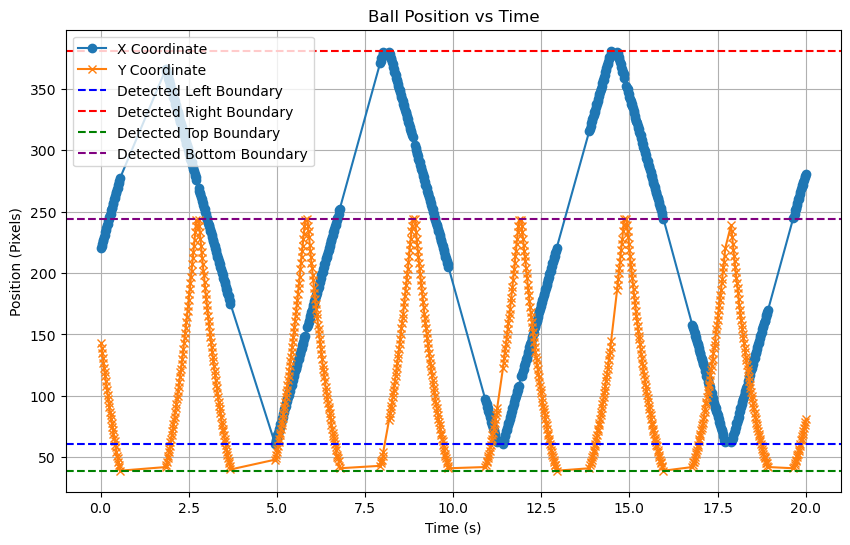

Collision Timestamps:
Boundary: Top, Time (s): 0.55
Boundary: Bottom, Time (s): 2.72
Boundary: Bottom, Time (s): 2.78
Boundary: Top, Time (s): 3.68
Boundary: Left, Time (s): 4.95
Boundary: Bottom, Time (s): 5.80
Boundary: Bottom, Time (s): 5.87
Boundary: Right, Time (s): 8.02
Boundary: Right, Time (s): 8.18
Boundary: Bottom, Time (s): 8.85
Boundary: Bottom, Time (s): 8.92
Boundary: Left, Time (s): 11.25
Boundary: Left, Time (s): 11.42
Boundary: Bottom, Time (s): 11.87
Boundary: Bottom, Time (s): 11.93
Boundary: Top, Time (s): 12.93
Boundary: Right, Time (s): 14.48
Boundary: Right, Time (s): 14.65
Boundary: Bottom, Time (s): 14.85
Boundary: Bottom, Time (s): 14.92
Boundary: Top, Time (s): 15.97
Boundary: Left, Time (s): 17.72
Boundary: Left, Time (s): 17.88


In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Initialize video capture
cap = cv2.VideoCapture('./video_only/video_only_ID_2.mp4')
fps = cap.get(cv2.CAP_PROP_FPS)

# Blob Detector Parameters for the Ball
params = cv2.SimpleBlobDetector_Params()
params.filterByArea = True
params.minArea = 20      # Minimum area of the dot
params.maxArea = 500     # Maximum area of the dot
params.filterByCircularity = True
params.minCircularity = 0.8  # Ensures dot is circular
detector = cv2.SimpleBlobDetector_create(params)

# Store data for plotting and analysis
time_data = []
x_data = []
y_data = []

# Process the video frame-by-frame
while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Convert to grayscale
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
    # Detect the Ball using blob detection
    keypoints = detector.detect(gray)
    if not keypoints:
        frame_number = cap.get(cv2.CAP_PROP_POS_FRAMES)
        missing_time = frame_number / fps
        print(f"Ball missing at time: {missing_time:.2f} sec")
    else:
        for kp in keypoints:
            x, y = int(kp.pt[0]), int(kp.pt[1])
            frame_number = cap.get(cv2.CAP_PROP_POS_FRAMES)
            
            # Store coordinates and time for plotting
            time_data.append(frame_number / fps)
            x_data.append(x)
            y_data.append(y)

cap.release()
cv2.destroyAllWindows()

# --- Compute extreme boundaries based on ball tracking data ---
if x_data and y_data:
    detected_left_boundary = min(x_data)
    detected_right_boundary = max(x_data)
    detected_top_boundary = min(y_data)
    detected_bottom_boundary = max(y_data)

    print("Detected boundaries from ball tracking data:")
    print(f"Left boundary: {detected_left_boundary}")
    print(f"Right boundary: {detected_right_boundary}")
    print(f"Top boundary: {detected_top_boundary}")
    print(f"Bottom boundary: {detected_bottom_boundary}")
else:
    print("No ball data was collected.")
    # Exit if no data was collected
    exit()

# --- Detect Collision Timestamps using the detected boundaries ---
# (This step still records collision events per frame)
collision_threshold = 2  # pixels
collision_timestamps = []
for t, x, y in zip(time_data, x_data, y_data):
    if abs(x - detected_left_boundary) < collision_threshold:
        collision_timestamps.append(("Left", t))
    if abs(x - detected_right_boundary) < collision_threshold:
        collision_timestamps.append(("Right", t))
    if abs(y - detected_top_boundary) < collision_threshold:
        collision_timestamps.append(("Top", t))
    if abs(y - detected_bottom_boundary) < collision_threshold:
        collision_timestamps.append(("Bottom", t))

# --- Create a Uniform Collision State Vector ---
# We'll sample at 100 Hz (i.e., 100 samples per second of video)
total_duration = time_data[-1]
sample_rate = 100  # samples per second
num_samples = int(total_duration * sample_rate)
t_uniform = np.linspace(0, total_duration, num=num_samples)

# Interpolate the tracked x and y positions to the uniform time vector
x_uniform = np.interp(t_uniform, time_data, x_data)
y_uniform = np.interp(t_uniform, time_data, y_data)

# Create a binary collision vector:
# A sample is marked as 1 if the ball's interpolated position is within the collision threshold
collision_state = (
    (np.abs(x_uniform - detected_left_boundary) < collision_threshold) |
    (np.abs(x_uniform - detected_right_boundary) < collision_threshold) |
    # (np.abs(y_uniform - detected_top_boundary) < collision_threshold) |
    (np.abs(y_uniform - detected_bottom_boundary) < collision_threshold)
).astype(int)

print("Collision state vector (0: no collision, 1: collision):")
print(collision_state)

# --- Plotting the Ball Position and Detected Boundaries ---
plt.figure(figsize=(10, 6))
plt.plot(time_data, x_data, label='X Coordinate', marker='o')
plt.plot(time_data, y_data, label='Y Coordinate', marker='x')

# Plot lines for the extreme boundaries
plt.axhline(y=detected_left_boundary, color='blue', linestyle='--', label='Detected Left Boundary')
plt.axhline(y=detected_right_boundary, color='red', linestyle='--', label='Detected Right Boundary')
plt.axhline(y=detected_top_boundary, color='green', linestyle='--', label='Detected Top Boundary')
plt.axhline(y=detected_bottom_boundary, color='purple', linestyle='--', label='Detected Bottom Boundary')

plt.xlabel('Time (s)')
plt.ylabel('Position (Pixels)')
plt.title('Ball Position vs Time')
plt.legend()
plt.grid(True)
plt.show()

# --- Print Collision Timestamps (Event-based) ---
print("Collision Timestamps:")
for boundary, t in collision_timestamps:
    print(f"Boundary: {boundary}, Time (s): {t:.2f}")


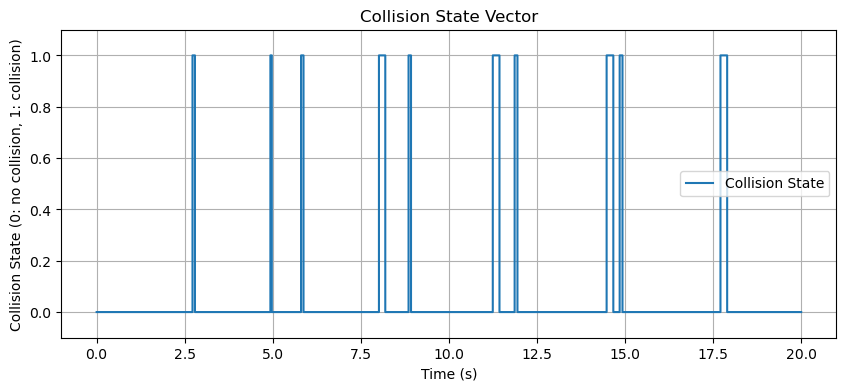

In [27]:
# --- Plot the Collision State Vector ---
plt.figure(figsize=(10, 4))
plt.step(t_uniform, collision_state, where='post', label='Collision State')
plt.xlabel('Time (s)')
plt.ylabel('Collision State (0: no collision, 1: collision)')
plt.title('Collision State Vector')
plt.ylim(-0.1, 1.1)
plt.grid(True)
plt.legend()
plt.show()


working properly (as expected) let us do it for all the videos

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_feat = []


for i in range (1,46):
    # Initialize video capture
    cap = cv2.VideoCapture(f'./video_only/video_only_ID_{i}.mp4')
    fps = cap.get(cv2.CAP_PROP_FPS)
    print (f'./video_only/video_only_ID_{i}.mp4 is being processed...')
    # Blob Detector Parameters for the Ball
    params = cv2.SimpleBlobDetector_Params()
    params.filterByArea = True
    params.minArea = 20      # Minimum area of the dot
    params.maxArea = 500     # Maximum area of the dot
    params.filterByCircularity = True
    params.minCircularity = 0.8  # Ensures dot is circular
    detector = cv2.SimpleBlobDetector_create(params)
    
    # Store data for plotting and analysis
    time_data = []
    x_data = []
    y_data = []
    
    # Process the video frame-by-frame
    while True:
        ret, frame = cap.read()
        if not ret:
            break
    
        # Convert to grayscale
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        
        # Detect the Ball using blob detection
        keypoints = detector.detect(gray)
        if not keypoints:
            frame_number = cap.get(cv2.CAP_PROP_POS_FRAMES)
            missing_time = frame_number / fps
            # print(f"Ball missing at time: {missing_time:.2f} sec")
        else:
            for kp in keypoints:
                x, y = int(kp.pt[0]), int(kp.pt[1])
                frame_number = cap.get(cv2.CAP_PROP_POS_FRAMES)
                
                # Store coordinates and time for plotting
                time_data.append(frame_number / fps)
                x_data.append(x)
                y_data.append(y)
    
    cap.release()
    cv2.destroyAllWindows()
    
    # --- Compute extreme boundaries based on ball tracking data ---
    if x_data and y_data:
        detected_left_boundary = min(x_data)
        detected_right_boundary = max(x_data)
        detected_top_boundary = min(y_data)
        detected_bottom_boundary = max(y_data)
    
        print("Detected boundaries from ball tracking data:")
        print(f"Left boundary: {detected_left_boundary}")
        print(f"Right boundary: {detected_right_boundary}")
        print(f"Top boundary: {detected_top_boundary}")
        print(f"Bottom boundary: {detected_bottom_boundary}")
    else:
        print("No ball data was collected.")
        # Exit if no data was collected
        exit()
    
    # --- Detect Collision Timestamps using the detected boundaries ---
    # (This step still records collision events per frame)
    collision_threshold = 2  # pixels
    collision_timestamps = []
    for t, x, y in zip(time_data, x_data, y_data):
        if abs(x - detected_left_boundary) < collision_threshold:
            collision_timestamps.append(("Left", t))
        if abs(x - detected_right_boundary) < collision_threshold:
            collision_timestamps.append(("Right", t))
        if abs(y - detected_top_boundary) < collision_threshold:
            collision_timestamps.append(("Top", t))
        if abs(y - detected_bottom_boundary) < collision_threshold:
            collision_timestamps.append(("Bottom", t))
    
    # --- Create a Uniform Collision State Vector ---
    # We'll sample at 100 Hz (i.e., 100 samples per second of video)
    total_duration = time_data[-1]
    sample_rate = 100  # samples per second
    num_samples = int(total_duration * sample_rate)
    t_uniform = np.linspace(0, total_duration, num=num_samples)
    
    # Interpolate the tracked x and y positions to the uniform time vector
    x_uniform = np.interp(t_uniform, time_data, x_data)
    y_uniform = np.interp(t_uniform, time_data, y_data)
    
    # Create a binary collision vector:
    # A sample is marked as 1 if the ball's interpolated position is within the collision threshold
    collision_state = (
        (np.abs(x_uniform - detected_left_boundary) < collision_threshold) |
        (np.abs(x_uniform - detected_right_boundary) < collision_threshold) |
        # (np.abs(y_uniform - detected_top_boundary) < collision_threshold) |
        (np.abs(y_uniform - detected_bottom_boundary) < collision_threshold)
    ).astype(int)
    
    image_feat.append(collision_state)

# print("Collision state vector (0: no collision, 1: collision):")
# print(collision_state)

# # --- Plotting the Ball Position and Detected Boundaries ---
# plt.figure(figsize=(10, 6))
# plt.plot(time_data, x_data, label='X Coordinate', marker='o')
# plt.plot(time_data, y_data, label='Y Coordinate', marker='x')

# # Plot lines for the extreme boundaries
# plt.axhline(y=detected_left_boundary, color='blue', linestyle='--', label='Detected Left Boundary')
# plt.axhline(y=detected_right_boundary, color='red', linestyle='--', label='Detected Right Boundary')
# plt.axhline(y=detected_top_boundary, color='green', linestyle='--', label='Detected Top Boundary')
# plt.axhline(y=detected_bottom_boundary, color='purple', linestyle='--', label='Detected Bottom Boundary')

# plt.xlabel('Time (s)')
# plt.ylabel('Position (Pixels)')
# plt.title('Ball Position vs Time')
# plt.legend()
# plt.grid(True)
# plt.show()

# # --- Print Collision Timestamps (Event-based) ---
# print("Collision Timestamps:")
# for boundary, t in collision_timestamps:
#     print(f"Boundary: {boundary}, Time (s): {t:.2f}")


./video_only/video_only_ID_1.mp4 is being processed...
Detected boundaries from ball tracking data:
Left boundary: 65
Right boundary: 377
Top boundary: 124
Bottom boundary: 245
./video_only/video_only_ID_2.mp4 is being processed...
Detected boundaries from ball tracking data:
Left boundary: 61
Right boundary: 381
Top boundary: 39
Bottom boundary: 244
./video_only/video_only_ID_3.mp4 is being processed...
Detected boundaries from ball tracking data:
Left boundary: 58
Right boundary: 382
Top boundary: 138
Bottom boundary: 245
./video_only/video_only_ID_4.mp4 is being processed...
Detected boundaries from ball tracking data:
Left boundary: 62
Right boundary: 382
Top boundary: 123
Bottom boundary: 245
./video_only/video_only_ID_5.mp4 is being processed...
Detected boundaries from ball tracking data:
Left boundary: 64
Right boundary: 378
Top boundary: 103
Bottom boundary: 245
./video_only/video_only_ID_6.mp4 is being processed...
Detected boundaries from ball tracking data:
Left boundary: 6

In [37]:
print (len(image_feat))
print (len(image_feat[5]))
print (image_feat)

45
2000
[array([0, 0, 0, ..., 0, 0, 0]), array([0, 0, 0, ..., 0, 0, 0]), array([0, 0, 0, ..., 0, 0, 0]), array([0, 0, 0, ..., 0, 1, 1]), array([0, 0, 0, ..., 0, 0, 0]), array([0, 0, 0, ..., 0, 0, 0]), array([0, 0, 0, ..., 0, 0, 0]), array([0, 0, 0, ..., 0, 0, 0]), array([0, 0, 0, ..., 0, 0, 0]), array([0, 0, 0, ..., 0, 0, 0]), array([0, 0, 0, ..., 0, 0, 0]), array([0, 0, 0, ..., 0, 0, 0]), array([0, 0, 0, ..., 0, 0, 0]), array([0, 0, 0, ..., 0, 0, 0]), array([0, 0, 0, ..., 0, 0, 0]), array([0, 0, 0, ..., 0, 0, 0]), array([0, 0, 0, ..., 0, 0, 0]), array([0, 0, 0, ..., 0, 0, 0]), array([0, 0, 0, ..., 1, 0, 0]), array([0, 0, 0, ..., 0, 0, 0]), array([0, 0, 0, ..., 0, 0, 1]), array([0, 0, 0, ..., 0, 0, 0]), array([0, 0, 0, ..., 0, 0, 0]), array([0, 0, 0, ..., 0, 0, 0]), array([0, 0, 0, ..., 0, 0, 0]), array([0, 0, 0, ..., 0, 0, 1]), array([0, 0, 0, ..., 0, 0, 0]), array([0, 0, 0, ..., 0, 0, 0]), array([0, 0, 0, ..., 0, 0, 0]), array([0, 0, 0, ..., 0, 0, 0]), array([0, 0, 0, ..., 0, 0, 0]),

In [39]:
import numpy as np

# Determine the maximum size along dimension 1
max_length = max(arr.shape[0] for arr in image_feat)

# Pad each array to match the maximum length
padded_image_feat = [np.pad(arr, (0, max_length - arr.shape[0]), mode='constant') for arr in image_feat]

# Convert the padded list to a 2D NumPy array
image_feat = np.vstack(padded_image_feat)

# Verify the shape
assert image_feat.shape == (45, max_length), "Reshape failed"

# Save to CSV for future use (kind of a checkpoint)
np.savetxt('image_features_extracted_openCV.csv', image_feat, delimiter=',', fmt='%d')


Plotting features for image features...


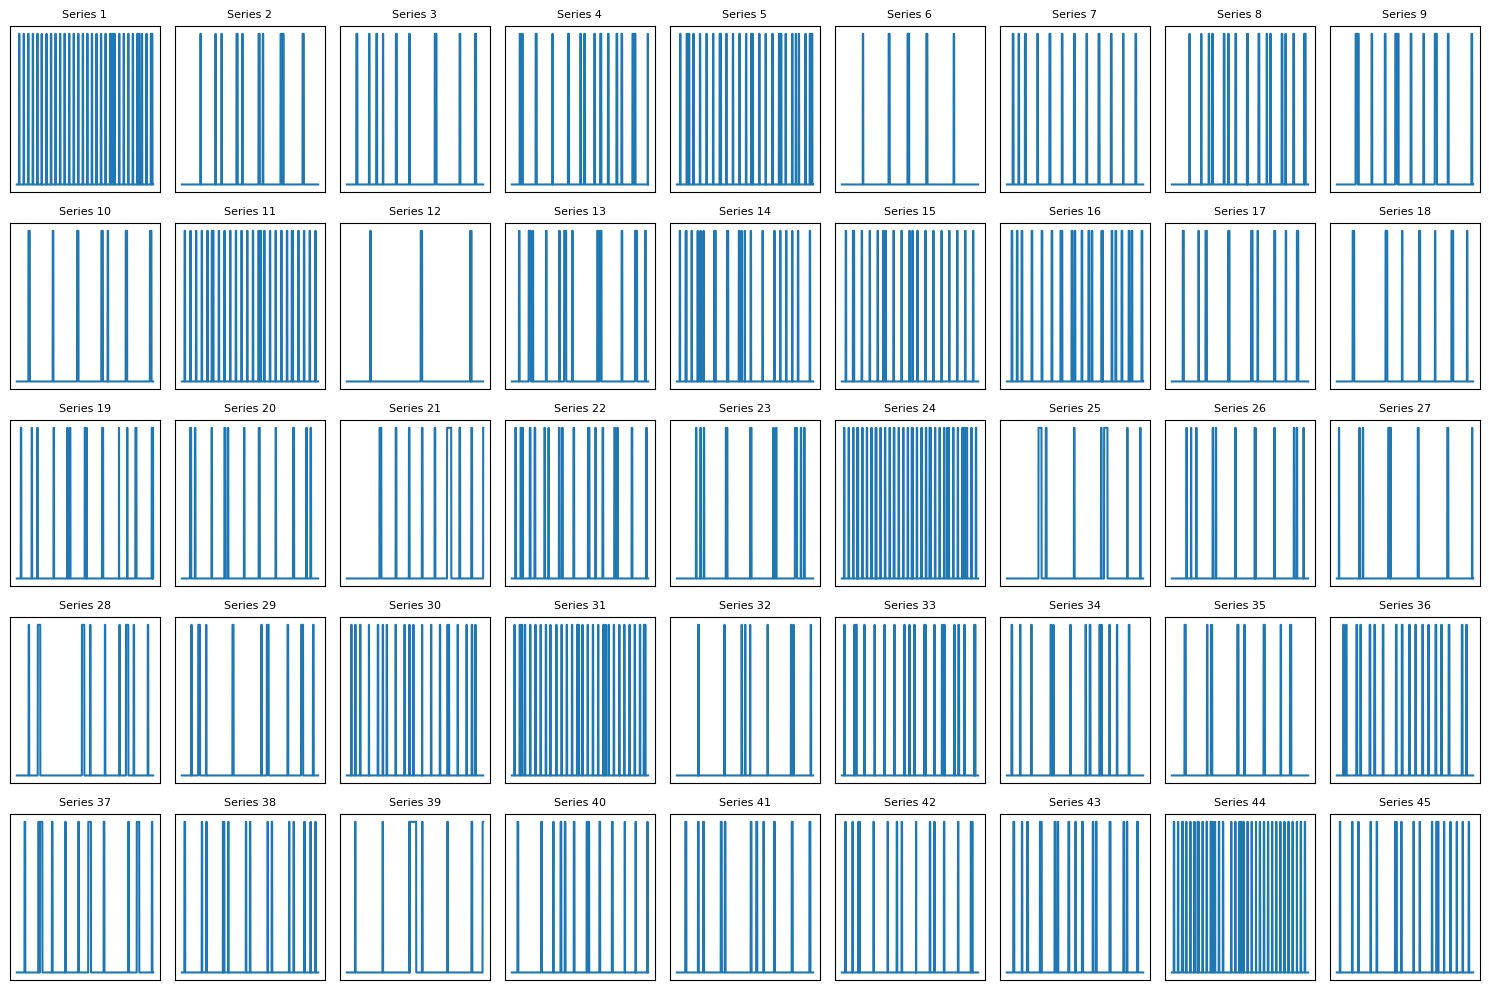

In [77]:
import matplotlib.pyplot as plt
import numpy as np
print ("Plotting features for image features...")

# Number of rows and columns for the grid
rows = 5
cols = 9  # Total 45 series = 5 x 9

plt.figure(figsize=(15, 10))

for i in range(image_feat.shape[0]):
    plt.subplot(rows, cols, i + 1) 
    plt.plot(image_feat[i], label=f'Series {i + 1}')
    plt.title(f'Series {i + 1}', fontsize=8)
    plt.xticks([])  # Hide x-axis ticks for cleaner visualization
    plt.yticks([]) 
    plt.grid(True)

plt.tight_layout()
plt.show()


# Now, I just have to extract audio features.
### Approach is to detect peaks using ```scipy.signal``` and then by interpolating it with the same sampling rate as of ```image_features``` I will make it a binary vector (1:peaks ; 0:normal)

In [109]:
import librosa
import numpy as np
from scipy.signal import find_peaks, peak_widths
import os

def extract_binary_vector(audio_path, num_samples=2000, duration=20):
    """
    Extracts a binary feature vector for an audio file by detecting peaks
    in the onset envelope and marking an interval around each peak as 1.
    
    Parameters:
    - audio_path: Path to the audio file.
    - num_samples: Length of the binary vector (default 2000).
    - duration: Duration of the audio in seconds (default 20).
    
    Returns:
    - binary_vector: A binary (0/1) numpy array of length num_samples.
    """
    # Load audio file
    y, sr = librosa.load(audio_path, sr=None)
    
    y_filtered = y
    
    # Compute onset envelope (energy function for percussive events)
    onset_env = librosa.onset.onset_strength(y=y_filtered, sr=sr)
    
    # Detect peaks in the onset envelope
    peaks, _ = find_peaks(onset_env, height=0.2)
    
    # Compute widths of the detected peaks (unpack 4 outputs)
    widths, _, left_ips, right_ips = peak_widths(onset_env, peaks, rel_height=0.5)
    
    # Initialize binary vector
    binary_vector = np.zeros(num_samples)
    # print (peaks)
    # For each detected peak, mark the interval as 1 in the binary vector
    for i in range(len(peaks)):
        # Convert the left and right positions (in onset envelope frame indices) to time (seconds)
        left_time = librosa.frames_to_time(left_ips[i], sr=sr)
        right_time = librosa.frames_to_time(right_ips[i], sr=sr)
        
        # Map times to indices in the binary vector
        left_index = int((left_time / duration) * num_samples)
        right_index = int((right_time / duration) * num_samples)
        # print (left_index)
        # Ensure indices are within bounds
        left_index = max(0, left_index)
        right_index = min(num_samples - 1, right_index)
        
        # Set the interval to 1
        binary_vector[left_index:right_index+1] = 1
        
    return binary_vector

# Parameters
num_samples = 2000   # Each audio file is represented as a vector of length 2000
total_files = 45     # Process 45 audio files
binary_features = np.zeros((total_files, num_samples), dtype=int)

# Process each audio file from audio_only_ID_1.wav to audio_only_ID_45.wav
for i in range(1, total_files + 1):
    audio_path = f'./audio_only/audio_only_ID_{i}.wav'
    binary_features[i-1] = extract_binary_vector(audio_path, num_samples=num_samples, duration=20)
    print(f"Processed: {audio_path}")

# Save the binary feature matrix to a CSV file
np.savetxt('audio_binary_features.csv', binary_features, delimiter=',', fmt='%d')
print("Binary feature extraction completed and saved as 'audio_binary_features.csv'.")
audio_features = binary_features

Processed: ./audio_only/audio_only_ID_1.wav
Processed: ./audio_only/audio_only_ID_2.wav
Processed: ./audio_only/audio_only_ID_3.wav
Processed: ./audio_only/audio_only_ID_4.wav
Processed: ./audio_only/audio_only_ID_5.wav
Processed: ./audio_only/audio_only_ID_6.wav
Processed: ./audio_only/audio_only_ID_7.wav
Processed: ./audio_only/audio_only_ID_8.wav
Processed: ./audio_only/audio_only_ID_9.wav
Processed: ./audio_only/audio_only_ID_10.wav
Processed: ./audio_only/audio_only_ID_11.wav
Processed: ./audio_only/audio_only_ID_12.wav
Processed: ./audio_only/audio_only_ID_13.wav
Processed: ./audio_only/audio_only_ID_14.wav
Processed: ./audio_only/audio_only_ID_15.wav
Processed: ./audio_only/audio_only_ID_16.wav
Processed: ./audio_only/audio_only_ID_17.wav
Processed: ./audio_only/audio_only_ID_18.wav
Processed: ./audio_only/audio_only_ID_19.wav
Processed: ./audio_only/audio_only_ID_20.wav
Processed: ./audio_only/audio_only_ID_21.wav
Processed: ./audio_only/audio_only_ID_22.wav
Processed: ./audio_

Plotting features for audio features...


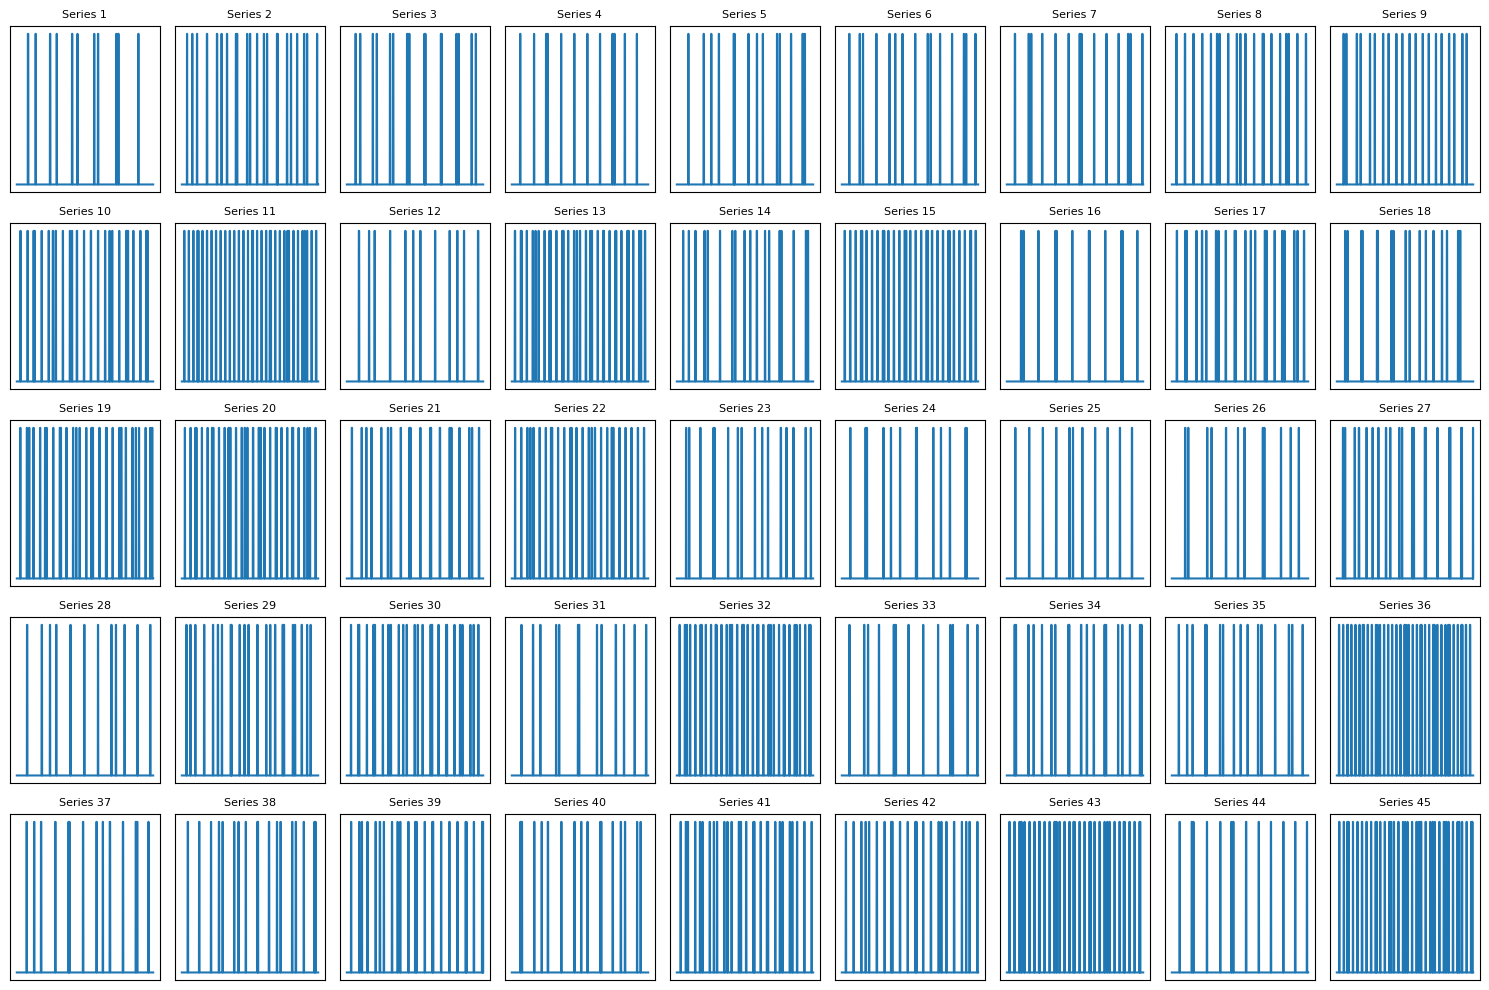

In [111]:
import matplotlib.pyplot as plt
import numpy as np
print ("Plotting features for audio features...")
# Number of rows and columns for the grid
rows = 5
cols = 9  # Total 45 series = 5 x 9

plt.figure(figsize=(15, 10))

for i in range(audio_features.shape[0]):
    plt.subplot(rows, cols, i + 1) 
    plt.plot(audio_features[i], label=f'Series {i + 1}')
    plt.title(f'Series {i + 1}', fontsize=8)
    plt.xticks([])  # Hide x-axis ticks for cleaner visualization
    plt.yticks([]) 
    plt.grid(True)

plt.tight_layout()
plt.show()


# Understanding the Matching Algorithm with Jaccard Similarity and Hungarian Algorithm
#### Now we just have to a similarity matching between these two sets. I am using Jaccard similarity as the vectors are binary.

## Understanding the Matching Algorithm with Jaccard Similarity and Hungarian Algorithm

This code aims to find the **best matching pairs** between two sets of binary vectors:

- **Image Features** (e.g., 45 vectors)
- **Audio Features** (e.g., 45 vectors)

The goal is to match **each Image Row** to **one Audio Row** such that their **Jaccard similarity** is maximized.

---

## Step 1: Computing the Jaccard Similarity Matrix

The **Jaccard Similarity** is a metric for comparing binary vectors. It measures how many bits are set to 1 in **both vectors** relative to the **total bits set to 1** in either vector.

$$
J(A, B) = \frac{| A \cap B |}{| A \cup B |}
$$

### Example:
- **Image Row:** `[1, 0, 1, 0, 1]`  
- **Audio Row:** `[1, 1, 0, 0, 1]`  

$$
J(A, B) = \frac{2}{4} = 0.5
$$

**Logic:**  
- The code iterates through **all possible pairs** of image and audio rows (\(O(n^2)\)) and computes their Jaccard similarity.  
- These values are stored in a **similarity matrix**, where each cell \((i, j)\) represents the similarity between **Image Row \(i\)** and **Audio Row \(j\)**.

---

## Step 2: Ensuring a One-to-One Matching (Permutation Constraint)

Simply finding the most similar audio row for each image row is **not enough**. Why?  
- Multiple image rows may want to match the **same audio row**.  
- We need a **global strategy** that pairs each image with a unique audio row.

### Solution: Hungarian Algorithm
The **Hungarian Algorithm** efficiently solves this **assignment problem** to ensure an **optimal one-to-one pairing**.

---

### Why Use the Hungarian Algorithm?
The Hungarian algorithm is ideal for this task because:

- It efficiently solves the **assignment problem** with a complexity of \(O(n^3)\), which is optimal for this type of problem.  
- Unlike greedy methods, it ensures a **global optimum**, meaning the total similarity score is maximized.  

### Key Steps in the Hungarian Algorithm:
1. **Cost Matrix Preparation:**  
   - Since the algorithm minimizes costs by default, we pass `-jaccard_similarities` (negative values) to effectively **maximize** similarity.
  
2. **Row and Column Reduction:**  
   - Each row and column is adjusted to ensure every row/column has at least one zero.

3. **Optimal Matching with Covering Lines:**  
   - The algorithm iteratively identifies the minimum number of covering lines required for zero entries. If this matches the number of rows/columns, the optimal solution is found.

4. **Assignment Extraction:**  
   - The algorithm identifies the **best pairs** that maximize total similarity.

---

## Step 3: Printing the Results
- Each image row is paired with one unique audio row.  
- The code prints each matched pair along with its similarity score.

**Example Output:**
- Image Row 1 matches Audio Row 3 with Jaccard Similarity 0.85
- Image Row 2 matches Audio Row 5 with Jaccard Similarity 0.72 ...

---

## Step 4: Heatmap Visualization
The heatmap shows the **Jaccard similarity matrix** in a clean and intuitive way:

- **White regions** indicate low similarity.
- **Dark red regions** indicate high similarity.

This visual helps identify patterns, clusters, or outliers in the similarity data.

---

Optimal Matching (Permutation):
Image Row 1 matches Audio Row 45 with Jaccard Similarity 0.4806
Image Row 2 matches Audio Row 1 with Jaccard Similarity 0.3852
Image Row 3 matches Audio Row 40 with Jaccard Similarity 0.3292
Image Row 4 matches Audio Row 18 with Jaccard Similarity 0.3618
Image Row 5 matches Audio Row 19 with Jaccard Similarity 0.5356
Image Row 6 matches Audio Row 31 with Jaccard Similarity 0.2564
Image Row 7 matches Audio Row 14 with Jaccard Similarity 0.3533
Image Row 8 matches Audio Row 38 with Jaccard Similarity 0.3729
Image Row 9 matches Audio Row 44 with Jaccard Similarity 0.3046
Image Row 10 matches Audio Row 23 with Jaccard Similarity 0.1793
Image Row 11 matches Audio Row 20 with Jaccard Similarity 0.4981
Image Row 12 matches Audio Row 24 with Jaccard Similarity 0.2022
Image Row 13 matches Audio Row 6 with Jaccard Similarity 0.3045
Image Row 14 matches Audio Row 13 with Jaccard Similarity 0.3644
Image Row 15 matches Audio Row 30 with Jaccard Similarity 0.4657
Imag

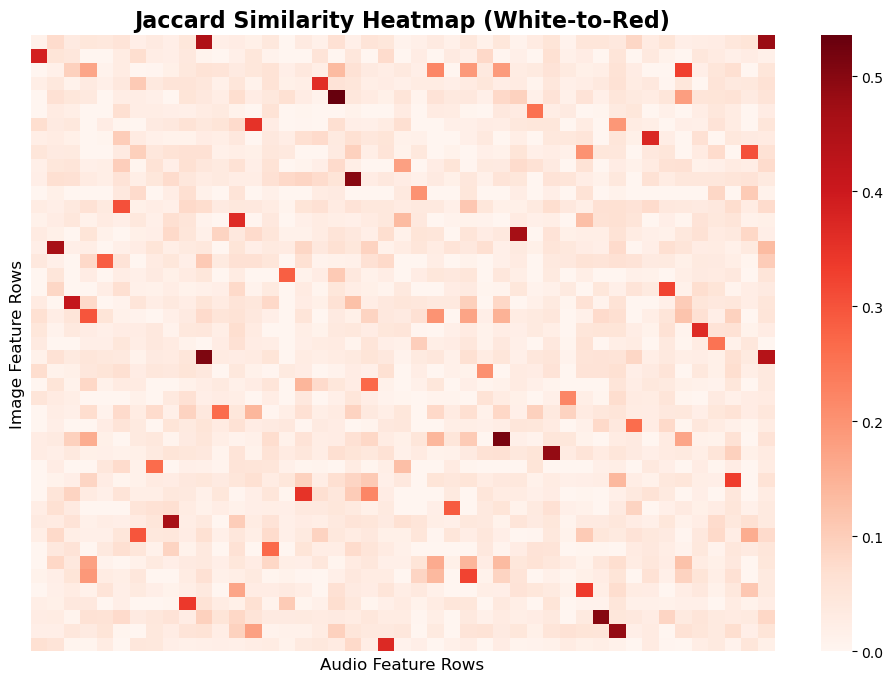

In [114]:
# Compute Jaccard similarity matrix
jaccard_similarities = np.zeros((image_features.shape[0], audio_features.shape[0]))

for i in range(image_features.shape[0]):
    for j in range(audio_features.shape[0]):
        jaccard_similarities[i, j] = jaccard_score(image_features[i], audio_features[j])

# Ensure matching is a permutation using Hungarian Algorithm
row_indices, col_indices = linear_sum_assignment(-jaccard_similarities)  # Maximize similarity

print("Optimal Matching (Permutation):")
for i, j in zip(row_indices, col_indices):
    print(f"Image Row {i+1} matches Audio Row {j+1} with Jaccard Similarity {jaccard_similarities[i, j]:.4f}")

# Heatmap Visualization
plt.figure(figsize=(12, 8))
sns.heatmap(
    jaccard_similarities, 
    cmap='Reds',          # White-to-Red gradient
    cbar=True,            # Add color bar
    xticklabels=False,    # Cleaner visualization
    yticklabels=False
)

plt.title('Jaccard Similarity Heatmap (White-to-Red)', fontsize=16, fontweight='bold')
plt.xlabel('Audio Feature Rows', fontsize=12)
plt.ylabel('Image Feature Rows', fontsize=12)
plt.show()

# Appendix:
## **Hungarian Algorithm Explained**
The **Hungarian Algorithm**, also known as the **Kuhn-Munkres algorithm**, is an optimal method for solving **assignment problems** in polynomial time. It efficiently finds the **maximum (or minimum) weighted matching** between two sets.

---

## **What is the Assignment Problem?**
Suppose we have:

- **n workers** and **n tasks**  
- Each worker can perform any task, but with **different costs** (or similarities).  
- The goal is to assign each worker to exactly one task in a way that:

 **Minimizes total cost** (or maximizes total similarity).  

### Example Matrix
|   | Task 1 | Task 2 | Task 3 |
|---|---------|---------|---------|
| **Worker 1** | 10 | 8 | 7 |
| **Worker 2** | 6 | 9 | 12 |
| **Worker 3** | 9 | 11 | 5 |

**Objective:** Minimize the total cost of assigning workers to tasks.

---

## **Steps of the Hungarian Algorithm**
The algorithm operates on a **cost matrix** (or similarity matrix for maximization problems) and follows these steps:

---

### **Step 1: Subtract Row Minimum**
- For each row, subtract the **smallest value** in that row from every element in the row.  
- This ensures each row contains **at least one zero**.

**Example:**
|   | Task 1 | Task 2 | Task 3 |
|---|---------|---------|---------|
| **Worker 1** | **3** | 1 | 0 |
| **Worker 2** | 0 | 3 | 6 |
| **Worker 3** | 4 | 6 | 0 |

---

### **Step 2: Subtract Column Minimum**
- For each column, subtract the **smallest value** in that column from every element in the column.  
- This ensures each column contains **at least one zero**.

**Updated Matrix:**  
|   | Task 1 | Task 2 | Task 3 |
|---|---------|---------|---------|
| **Worker 1** | **3** | 0 | 0 |
| **Worker 2** | 0 | 2 | 6 |
| **Worker 3** | 4 | 5 | 0 |

---

### **Step 3: Cover All Zeros Using Minimum Lines**
- Draw the **minimum number of horizontal/vertical lines** required to cover all the zeros.  
- If the number of lines equals **n** (the matrix size), proceed to Step 5.  
- If fewer than **n** lines are drawn, continue to Step 4.

---

### **Step 4: Adjust Matrix**
- Find the **smallest uncovered element** (let's call it `min_uncovered`).  
- Subtract `min_uncovered` from all uncovered elements.  
- Add `min_uncovered` to elements that are **covered twice** (intersection of two lines).

This step creates additional zeros while maintaining optimal conditions.

---

### **Step 5: Optimal Assignment**
- Identify **one zero in each row and column** such that no two chosen zeros are in the same row or column.  
- This represents the optimal assignment.

---

## **Why Does This Work for Maximizing Similarity?**
The Hungarian Algorithm is designed to **minimize** costs.  
- To **maximize similarity**, we pass the **negative of the similarity matrix**.  
- This turns maximizing the similarity into minimizing the "negative similarity," which fits the algorithm's logic.

---

## **Complexity Analysis**
- The algorithm runs in **O(n³)**, making it efficient for reasonably large datasets.

---


